<a href="https://colab.research.google.com/github/GwangseongCho/Projects/blob/main/Lung_Cancer_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive

# Connect to Google Drive
drive.mount('/content/drive')

# Load the original CSV file
file_path = '/content/drive/MyDrive/Lung_Cancer_Data/Cleaned_Lung_Cancer_dataset.csv'
df = pd.read_csv(file_path)

# 1. Merge Cancer Cell Type categories
# Reason: There are many subtypes of NSCLC (non-small cell lung carcinoma) and rare types
# in the original dataset. Merging subtypes into broader categories reduces sparsity,
# ensures each category has enough samples for statistical modeling,
# and simplifies the Bayesian network structure.
cell_type_map = {
    'NSCLC-Adenocarcinoma, NOS': 'NSCLC-Adenocarcinoma',
    'NSCLC-lepidic predominant adenocarcinoma': 'NSCLC-Adenocarcinoma',
    'NSCLC-Solid Predominant Adenocarcinoma': 'NSCLC-Adenocarcinoma',
    'NSCLC-Papillary Predominant Adenocarcinoma': 'NSCLC-Adenocarcinoma',
    'NSCLC-Adenocarcinoma w/ Mixed Subtypes': 'NSCLC-Adenocarcinoma',
    'NSCLC-Squamous, NOS': 'NSCLC-Squamous',
    'NSCLC-Adenosquamous Carcinoma': 'Other NSCLC',
    'NSCLC-Large Cell Neuroendocrine Carcinoma': 'Other NSCLC',
    'NSCLC-NOS': 'Other NSCLC',
    'Typical Carcinoid': 'Neuroendocrine / Carcinoid',
    'Neuroendocrine Carcinoma': 'Neuroendocrine / Carcinoid',
    'Malignant Tumor Cells, NOS': 'Malignant / Carcinoma NOS',
    'Carcinoma, NOS': 'Malignant / Carcinoma NOS',
    'Other / Rare': 'Other / Rare',
    'Not Lung Cancer': 'Not Lung Cancer'
}
df['Cancer Cell Type'] = df['Cancer Cell Type'].map(cell_type_map)

# 2. Merge Regional Lymph Node Involvement categories
# Reason: Original dataset has multiple detailed lymph node statuses.
# For modeling purposes, simplifying to 'Nodal Involvement', 'No Nodal Involvement',
# and 'Unknown / NA' reduces sparsity, avoids overfitting, and makes causal relationships
# more interpretable in Bayesian networks.
node_map = {
    'No Nodal Involvement': 'No Nodal Involvement',
    'Mediastinal Ipsilateral': 'Nodal Involvement',
    'Bilateral / Contralateral': 'Nodal Involvement',
    'Ipsilateral Nodes Only': 'Nodal Involvement',
    'Ipsilateral / Contralateral': 'Nodal Involvement',
    'Node Involvement, NOS': 'Nodal Involvement',
    'Regional Node Involvement, NOS': 'Nodal Involvement',
    'Unknown Node Status': 'Unknown / NA',
    'Not Applicable': 'Unknown / NA'
}
df['Regional Lymph Node Involvement'] = df['Regional Lymph Node Involvement'].map(node_map)

# 3. Bin Days from Diagnosis to Treatment
# Reason: Original 'Days from Diagnosis' is continuous with high variability.
# Binning into categories ('<=3 months', '<=1 year', '>1 year') simplifies the data,
# reduces noise, and allows the Bayesian network to capture temporal patterns without
# being affected by outliers or extreme values.
def days_bin(x):
    if x <= 90:   # 3 months or less
        return '<=3 months'
    elif x <= 365:
        return '<=1 year'
    else:
        return '>1 year'
df['Days from Diagnosis to Treatment'] = df['Days from Diagnosis to Treatment'].apply(days_bin)

# 4. Merge Metastatic Spread categories
# Reason: Original dataset lists multiple specific metastatic sites.
# Combining into 'Distant Metastasis', 'No Distant Metastasis', and 'Unknown / NA'
# reduces sparsity and allows clearer modeling of the causal impact of metastasis on
# treatment outcomes and survival.
metastatic_map = {
    'No Distant Metastasis': 'No Distant Metastasis',
    'Lung': 'Distant Metastasis',
    'Distant Lymph Node': 'Distant Metastasis',
    'Other Specified Distant Metastasis': 'Distant Metastasis',
    'Distant Metastasis, NOS': 'Distant Metastasis',
    'Unknown': 'Unknown / NA',
    'Entry Error': 'Unknown / NA'
}
df['Metastatic Spread'] = df['Metastatic Spread'].map(metastatic_map)

# 5. Merge Tumor Laterality categories
# Reason: Original laterality has multiple levels (Right, Left, Bilateral, etc.).
# Combining Right and Left simplifies the analysis while still retaining the important distinction
# of Bilateral vs. Single side. 'Unknown / NA' handles missing or inapplicable cases.
laterality_map = {
    'Right': 'Right / Left',
    'Left': 'Right / Left',
    'Bilateral': 'Bilateral',
    'Unspecified': 'Unknown / NA',
    'Only One Side, NOS': 'Unknown / NA',
    'Inapplicable': 'Unknown / NA'
}
df['Tumor Laterality'] = df['Tumor Laterality'].map(laterality_map)

# 6. Merge Extent of Regional Lymph Node Surgery categories
# Reason: Multiple surgery types exist, some rare. Grouping into 'Nodes Removed / Dissection',
# 'Biopsy Only', and 'Unknown / NA' reduces sparsity and simplifies modeling the effect of surgery.
surgery_map = {
    '4+ Nodes Removed': 'Nodes Removed / Dissection',
    '1-3 Nodes Removed': 'Nodes Removed / Dissection',
    'Sentinel Biopsy + Dissection': 'Nodes Removed / Dissection',
    'Sentinel Biopsy only': 'Nodes Removed / Dissection',
    'Node(s) Removed, NOS': 'Nodes Removed / Dissection',
    'Regional Biopsy/aspiration only': 'Biopsy Only',
    'Unknown/Inapplicable': 'Unknown / NA'
}
df['Extent of Regional Lymph Node Surgery'] = df['Extent of Regional Lymph Node Surgery'].map(surgery_map)


# 7. Merge Treatment Plan categories
# Reason: Original treatment plan is detailed with combinations of surgery, chemo, radiotherapy.
# Merging into broader categories reduces sparsity, prevents overfitting, and allows the Bayesian network
# to capture meaningful causal relationships without too many rare combinations.
treatment_map = {
    'Surgery': 'Surgery',
    'Radiotherapy': 'Radiotherapy',
    'Radiotherapy after Surgery': 'Radiotherapy',
    'Chemotherapy': 'Chemotherapy / Combined',
    'Chemotherapy after Surgery': 'Chemotherapy / Combined',
    'Chemotherapy and Radiotherapy': 'Chemotherapy / Combined',
    'Chemotherapy and Radiotherapy after Surgery': 'Chemotherapy / Combined',
    'Radiotherapy and Chemotherapy before Surgery': 'Chemotherapy / Combined',
    'Chemotherapy before Surgery': 'Chemotherapy / Combined',
    'Refused Treatment': 'Refused',
    'Other': 'Other',
    'Unknown Treatment': 'Unknown / NA'
}
df['Treatment Plan'] = df['Treatment Plan'].map(treatment_map)

# 8. Save the cleaned and recategorized CSV
output_path = '/content/drive/MyDrive/Lung_Cancer_Data/Recategorized_Cleaned_Lung_Cancer_dataset.csv'
df.to_csv(output_path, index=False)

print("Recategorized CSV file successfully created:", output_path)

Mounted at /content/drive
Recategorized CSV file successfully created: /content/drive/MyDrive/Lung_Cancer_Data/Recategorized_Cleaned_Lung_Cancer_dataset.csv


In [ ]:
!pip3 install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 48.7 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Consistently learned edges across all runs:
('Tumor_Location', 'Tumor_Extent_at_Diagnosis')
('Cancer_Cell_Type', 'Age')
('Tumor_Extent_at_Diagnosis', 'Regional_Lymph_Node_Involvement')
('Tumor_Extent_at_Diagnosis', 'Metastatic_Spread')
('Tumor_Extent_at_Diagnosis', 'Treatment_Plan')
('Regional_Lymph_Node_Involvement', 'Treatment_Plan')
('Regional_Lymph_Node_Involvement', 'Metastatic_Spread')
('Regional_Lymph_Node_Involvement', 'Days_from_Diagnosis_to_Treatment')
('Regional_Lymph_Node_Involvement', 'Extent_of_Regional_Lymph_Node_Surgery')
('Regional_Lymph_Node_Involvement', 'Cancer_Cell_Type')
('Regional_Lymph_Node_Involvement', 'Cause_of_Death')
('Metastatic_Spread', 'Cancer_Cell_Type')
('Metastatic_Spread', 'Cause_of_Death')
('Metastatic_Spread', 'Extent_of_Regional_Lymph_Node_Surgery')
('Metastatic_Spread', 'Days_from_Diagnosis_to_Treatment')
('Tumor_Laterality', 'Tumor_Location')
('Tumor_Laterality', 'Tumor_Extent_at_Diagnosis')
('Tumor_Laterality', 'Regional_Lymph_Node_Involvement'

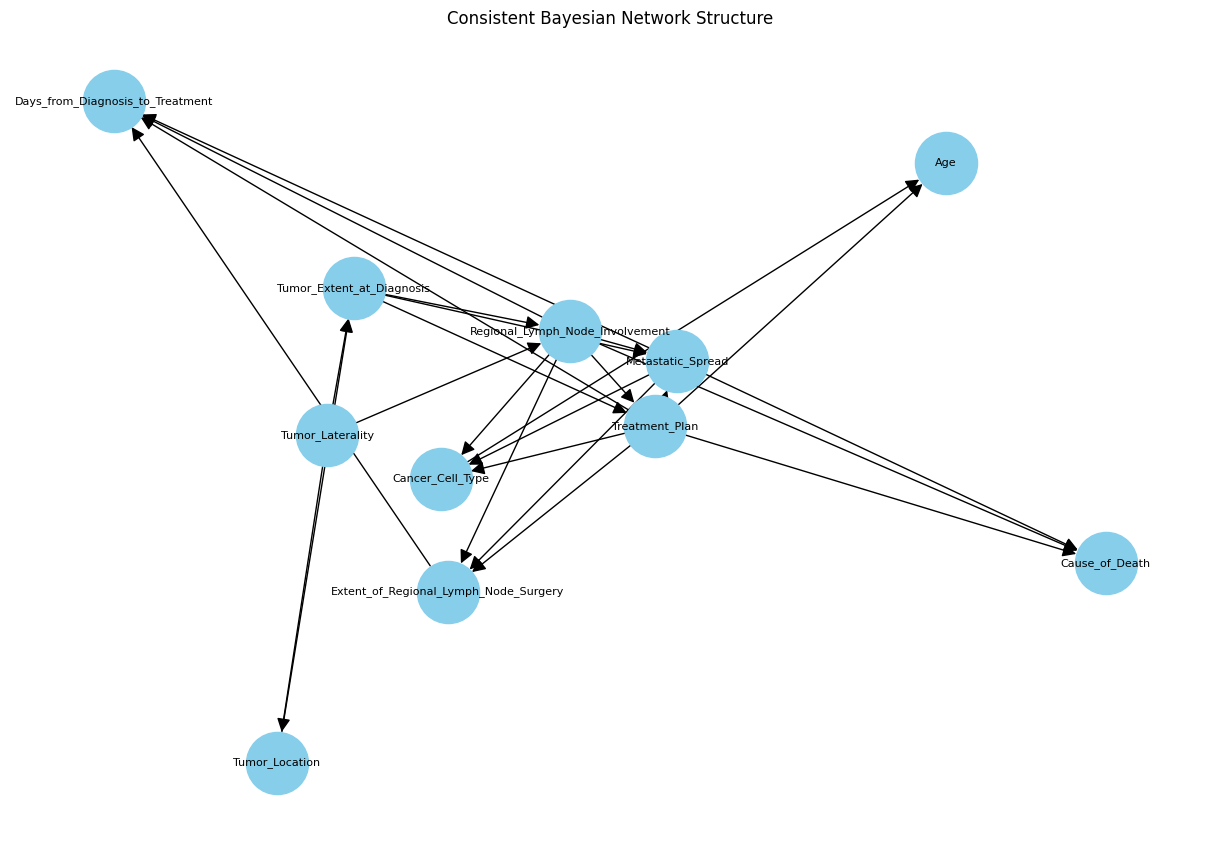

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.estimators import HillClimbSearch, BIC
import pandas as pd
from google.colab import drive
from collections import Counter

drive.mount('/content/drive')

# 1. Load dataset
df = pd.read_csv(
    '/content/drive/MyDrive/Lung_Cancer_Data/Recategorized_Cleaned_Lung_Cancer_dataset.csv'
)

# 2. Replace spaces in column names and convert all columns to categorical strings
df.columns = [col.replace(' ', '_') for col in df.columns]

for col in df.columns:
    df[col] = df[col].astype(str)

# 3. Learn Bayesian Network structure multiple times
num_runs = 5  # number of iterations
all_edges = []

for _ in range(num_runs):
    hc = HillClimbSearch(df)
    estimated_model = hc.estimate(
        scoring_method=BIC(df), max_iter=int(1e4))

    all_edges.extend(estimated_model.edges())

# 4. Extract edges that appear in all runs (consistent edges)
edge_counts = Counter(all_edges)
consistent_edges = [edge for edge,
                    count in edge_counts.items() if count == num_runs]

print("Consistently learned edges across all runs:")
for edge in consistent_edges:
    print(edge)

# 5. Visualize the consistent structure
plt.figure(figsize=(12, 8))
G = nx.DiGraph()
G.add_edges_from(consistent_edges)

pos = nx.spring_layout(G, k=1,seed=100)
nx.draw(
    G, pos, with_labels=True, node_size=2000, node_color='skyblue',
    arrowsize=20, font_size=8
)
plt.title("Consistent Bayesian Network Structure")
plt.show()
